In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

sns.set_theme(font_scale=1.4, style="white")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
})

N_TARGETS = 20
SOURCE_POS = np.array([0.0, 0.0])

rng = np.random.default_rng(12)
target_x = np.sort(rng.uniform(1.4, 10.0, N_TARGETS))
y_centers = rng.choice([-2.9, -1.4, 0.6, 2.4], size=N_TARGETS, p=[0.2, 0.35, 0.3, 0.15])
target_y = y_centers + rng.normal(0.0, 0.42, N_TARGETS)
TARGET_POS = np.column_stack([target_x, target_y])


def connection_probability(x_values):
    x_scaled = x_values / x_values.max()
    return np.clip(0.9 * np.exp(-3.8 * x_scaled**2) + 0.02, 0.02, 0.9)


def build_original_edges(seed=5, min_edges=5, max_edges=5):
    local_rng = np.random.default_rng(seed)
    probs = connection_probability(target_x)

    near_pool = np.argsort(probs)[-10:]
    near_weights = probs[near_pool] / probs[near_pool].sum()
    near_targets = local_rng.choice(near_pool, size=4, replace=False, p=near_weights)

    long_target = int(np.argmax(target_x))
    selected = np.sort(np.concatenate([near_targets, [long_target]]))

    x_scaled = target_x[selected] / target_x.max()
    mean_syn = 1.0 + 4.8 * (1.0 - x_scaled) ** 2
    syn_counts = np.clip(local_rng.poisson(mean_syn) + 1, 1, 6)

    long_pos = int(np.where(selected == long_target)[0][0])
    syn_counts[long_pos] = max(2, min(3, syn_counts[long_pos]))

    edges = []
    for edge_id, (target_idx, syn_count) in enumerate(zip(selected, syn_counts)):
        edges.append({
            "id": edge_id,
            "target": int(target_idx),
            "syn_count": int(syn_count),
        })

    return edges


EDGE_CMAP = plt.get_cmap("tab10")
EDGE_COLORS = [EDGE_CMAP(i % 10) for i in range(20)]

In [54]:
def edge_length(edge):
    return float(np.linalg.norm(TARGET_POS[edge["target"]] - SOURCE_POS))


def total_length(edges):
    return float(sum(edge_length(edge) * edge["syn_count"] for edge in edges))


def clone_edges(edges):
    return [dict(edge) for edge in edges]


def randomize_unconstrained(edges, seed=0):
    rng = np.random.default_rng(seed)
    randomized = clone_edges(edges)

    available_targets = np.array(sorted(set(range(N_TARGETS)) - {edge["target"] for edge in edges}), dtype=int)
    farthest = available_targets[np.argsort(target_x[available_targets])[-len(edges):]]
    chosen_targets = farthest[rng.permutation(len(farthest))]

    edge_order = np.argsort([edge_length(edge) for edge in edges])
    for edge_idx, new_target in zip(edge_order, chosen_targets):
        randomized[edge_idx]["target"] = int(new_target)

    return randomized


def prune_connections(unconstrained_edges, keep_fraction=0.6, seed=0):
    rng = np.random.default_rng(seed)
    n_remove = int(round(len(unconstrained_edges) * (1.0 - keep_fraction)))
    remove_idx = set(rng.choice(len(unconstrained_edges), size=n_remove, replace=False).tolist())
    return [dict(edge) for idx, edge in enumerate(unconstrained_edges) if idx not in remove_idx]


def randomize_binned(edges, seed=0):
    rng = np.random.default_rng(seed)
    randomized = clone_edges(edges)

    original_targets = {edge["target"] for edge in edges}
    available_targets = list(sorted(set(range(N_TARGETS)) - original_targets))
    available_distances = {target: float(np.linalg.norm(TARGET_POS[target] - SOURCE_POS)) for target in available_targets}

    order = rng.permutation(len(edges))
    for edge_idx in order:
        original_distance = edge_length(edges[edge_idx])
        ranked_targets = sorted(
            available_targets,
            key=lambda target: abs(available_distances[target] - original_distance),
        )
        pick_pool = ranked_targets[: min(3, len(ranked_targets))]
        new_target = int(rng.choice(pick_pool))
        randomized[edge_idx]["target"] = new_target
        available_targets.remove(new_target)

    return randomized


def randomize_width_only(edges, seed=0):
    rng = np.random.default_rng(seed)
    randomized = clone_edges(edges)
    syn_counts = np.array([edge["syn_count"] for edge in edges], dtype=int)
    shuffled = rng.permutation(syn_counts)
    if np.array_equal(shuffled, syn_counts) and len(shuffled) > 1:
        shuffled = np.roll(shuffled, 1)
    for edge, syn_count in zip(randomized, shuffled):
        edge["syn_count"] = int(syn_count)
    return randomized


def strand_radii(edge):
    count = edge["syn_count"]
    tx, ty = TARGET_POS[edge["target"]]
    base = 0.09 * np.sign(ty) if abs(ty) > 0.25 else 0.10
    spread = min(0.42, 0.055 * max(count - 1, 1))
    if count == 1:
        return [base]
    return list(base + np.linspace(-spread, spread, count))


def draw_edge(ax, edge, alpha=1.0, zorder=2):
    sx, sy = SOURCE_POS
    tx, ty = TARGET_POS[edge["target"]]
    color = EDGE_COLORS[edge["id"]]

    for rad in strand_radii(edge):
        patch = FancyArrowPatch(
            (sx, sy),
            (tx, ty),
            arrowstyle="-",
            connectionstyle=f"arc3,rad={rad}",
            linewidth=0.95,
            color=color,
            alpha=alpha,
            zorder=zorder,
            capstyle="round",
            joinstyle="round",
        )
        ax.add_patch(patch)


def get_display_target_indices():
    edge_sets = [
        ORIGINAL_EDGES,
        UNCONSTRAINED_EDGES,
        CONNECTION_PRUNED_EDGES,
        BINNED_EDGES,
        WIDTH_ONLY_EDGES,
    ]
    return np.array(sorted({edge["target"] for edges in edge_sets for edge in edges}), dtype=int)


def draw_nodes(ax):
    display_idx = get_display_target_indices()
    display_pos = TARGET_POS[display_idx]

    ax.scatter(
        display_pos[:, 0],
        display_pos[:, 1],
        s=62,
        facecolor="white",
        edgecolor="#334155",
        linewidth=1.0,
        zorder=5,
    )

    for idx, (x, y) in zip(display_idx, display_pos):
        dy = 0.24 if idx % 2 == 0 else -0.30
        va = "bottom" if idx % 2 == 0 else "top"
        ax.text(x + 0.06, y + dy, f"T{idx + 1}", fontsize=9.5, color="#64748B", ha="left", va=va)

    ax.scatter(SOURCE_POS[0], SOURCE_POS[1], s=120, facecolor="white", edgecolor="#111827", linewidth=2.0, zorder=6)
    if False:
        ax.text(
            SOURCE_POS[0] - 0.12,
            SOURCE_POS[1] - 0.42,
            "source",
            ha="left",
            va="top",
            fontsize=10.5,
            color="#111827",
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=1.8),
        )


def style_axis(ax):
    display_idx = get_display_target_indices()
    display_x = target_x[display_idx]
    display_y = target_y[display_idx]

    ax.set_xlim(-0.45, display_x.max() + 0.7)
    ax.set_ylim(display_y.min() - 1.0, display_y.max() + 1.0)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines["bottom"].set_color("#CBD5E1")
    ax.tick_params(axis="x", bottom=False, labelbottom=False)
    for x in np.arange(0, np.ceil(display_x.max()) + 0.5, 1):
        ax.axvline(x, color="#F8FAFC", lw=0.8, zorder=0)


def draw_panel(i, ax, edges, title):
    # Add the panel letter
    style_axis(ax)
    for edge in sorted(edges, key=lambda edge: edge["syn_count"]):
        draw_edge(ax, edge, alpha=0.95, zorder=2)
    draw_nodes(ax)
    ax.text(0.01, 1.02, f"{chr(ord('a') + i)}", transform=ax.transAxes, ha="left", va="bottom", fontsize=20, fontweight="bold", color="#111827")
    ax.text(0.1, 1.02, title, transform=ax.transAxes, ha="left", va="bottom", fontsize=16, color="#111827")

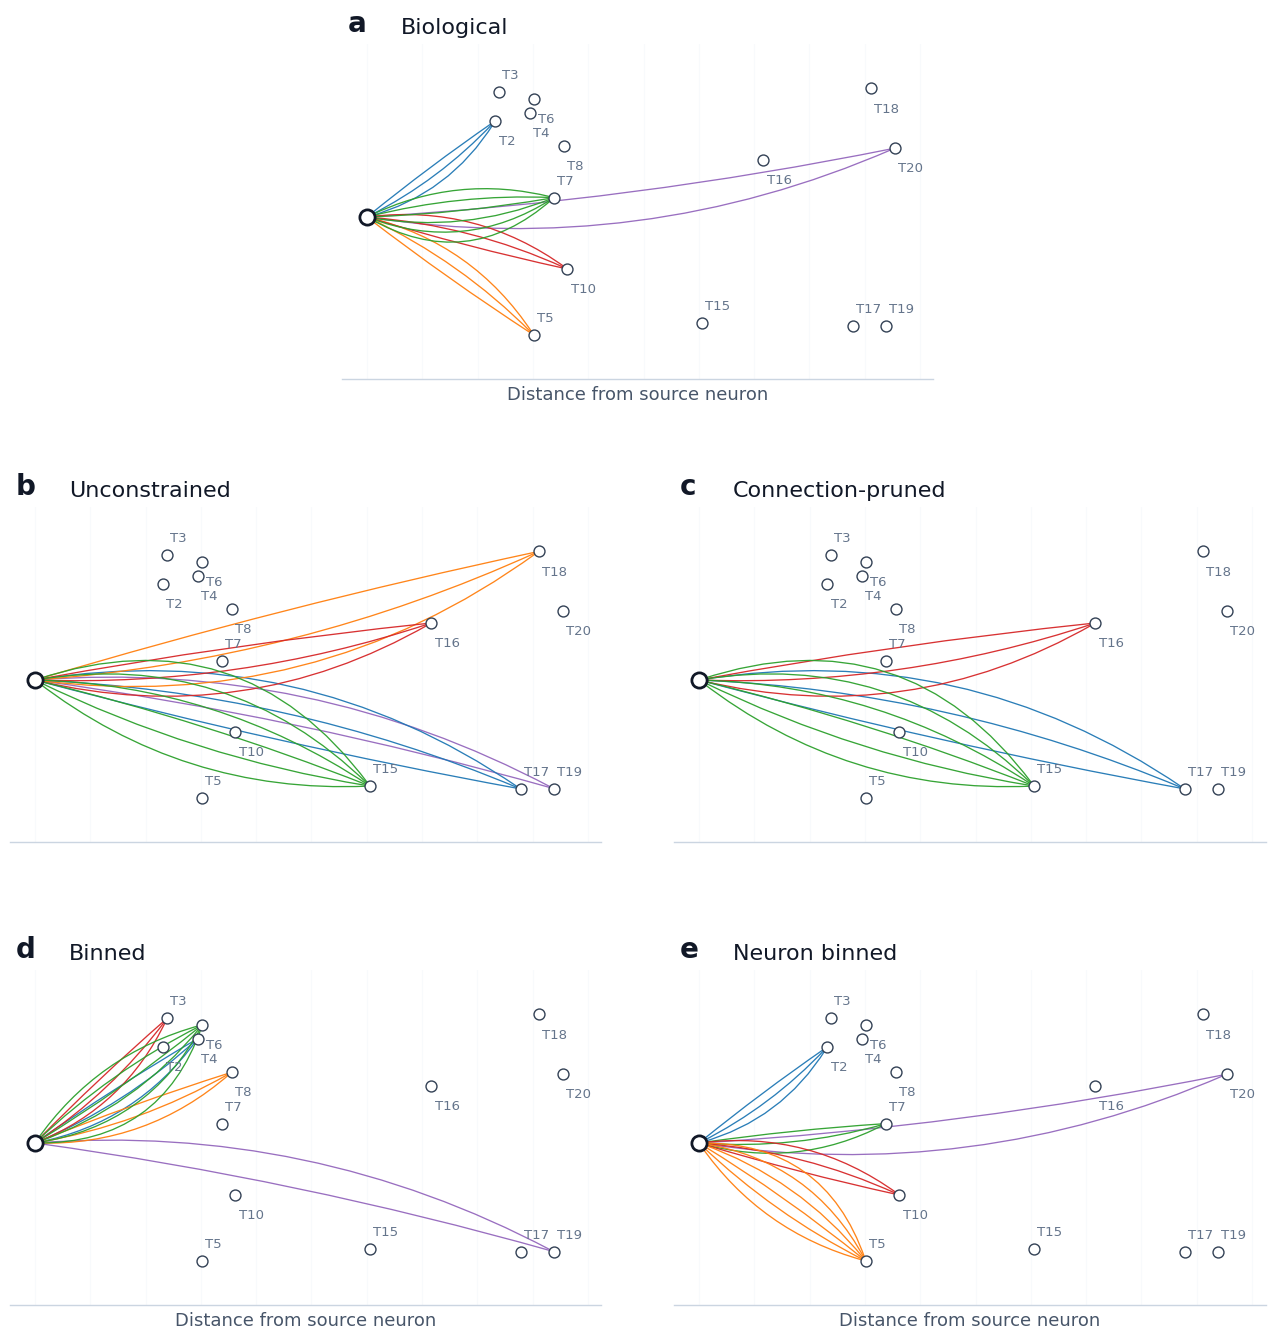

In [55]:
import importlib

from notebooks.visualization.random_networks_plots import randomization_strategies
from connectome.visualization import RANDOMIZATION_NAMES, apply_plot_style

importlib.reload(randomization_strategies)
apply_plot_style()

width_only_edges = [
    {"id": 0, "target": 1, "syn_count": 3},
    {"id": 1, "target": 4, "syn_count": 6},
    {"id": 2, "target": 6, "syn_count": 3},
    {"id": 3, "target": 9, "syn_count": 3},
    {"id": 4, "target": 19, "syn_count": 2},
]

titles = {
    "biological": RANDOMIZATION_NAMES["biological"],
    "unconstrained": RANDOMIZATION_NAMES["unconstrained"],
    "connection_pruned": RANDOMIZATION_NAMES["connection_pruned"],
    "random_binned": RANDOMIZATION_NAMES["random_binned"],
    "width_only": RANDOMIZATION_NAMES["neuron_binned"],
}

fig = randomization_strategies.create_randomization_strategies_figure(
    width_only_edges_override=width_only_edges,
    titles=titles,
    apply_theme=False,
)
plt.subplots_adjust(left=0.05, right=0.98, top=0.93, bottom=0.06)
plt.savefig("randomization_strategies.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()